# Gate C1 — пятиseedовый compact sequence temporal screen

## TL;DR

Четыре заранее зафиксированные sequence-архитектуры прошли nested train-only temporal screen на 11 rolling-origin folds и пяти seeds. Лучшая deep-модель по canonical ensemble MAE — **`C01_compact_gru`**, MAE **6.288 мм/год**. В C2 допущены: **C01_compact_gru**.

Результат имеет границу `train_only_internal_research`. Исторический validation, раскрытый test и отсутствующий future/external holdout не загружались. Leave-profile, leave-zone, transition audit, conformal calibration и suite v5 в C1 не выполнялись.

## Метод и provenance

- 11 forward-only outer folds, последние 3 допустимых inner folds на каждый outer context;
- 56 frozen configurations, пять seeds `42117–42121` без отбора seed;
- canonical point prediction — среднее пяти фиксированных seeds;
- worker сохраняет unlabeled shards, scorer присоединяет outer labels только после hash freeze всех 44 shards;
- B1/B7/B8 импортированы как неизменяемые comparators на тех же 595 origins.

Notebook читает только сохранённые C1 CSV/JSON/PNG, ничего не обучает и не импортирует model adapters.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

root = Path.cwd().resolve()
while not (root / 'pyproject.toml').is_file():
    root = root.parent
artifact = root / 'artifacts' / 'model_selection' / 't1_gate_c1_compact_screen_v1'
aggregate = pd.read_csv(artifact / 'temporal_aggregate_metrics.csv')
folds = pd.read_csv(artifact / 'temporal_fold_metrics.csv')
seeds = pd.read_csv(artifact / 'seed_stability_metrics.csv')
screen = pd.read_csv(artifact / 'screening_register.csv')
native = pd.read_csv(artifact / 'student_t_native_metrics.csv')
compute = pd.read_csv(artifact / 'compute_resource_inventory.csv')
checkpoints = pd.read_csv(artifact / 'checkpoint_inventory.csv')
incidents = json.loads((artifact / 'execution_incident_register.json').read_text(encoding='utf-8'))
validation = json.loads((artifact / 'validation_report.json').read_text(encoding='utf-8'))
admission = json.loads((artifact / 'c2_admission_manifest.json').read_text(encoding='utf-8'))
ledger = json.loads((artifact / 'outer_label_access_ledger.json').read_text(encoding='utf-8'))
figures = json.loads((artifact / 'figure_manifest.json').read_text(encoding='utf-8'))
{
    'status': validation['status'],
    'scope': validation['scientific_scope'],
    'admitted_to_c2': admission['admitted_model_ids'],
    'checks': (validation['check_count'], validation['failed_checks']),
    'scored_rows': validation['scored_prediction_rows'],
}

{'status': 'PASS_C1_TEMPORAL_SCREEN',
 'scope': 'train_only_internal_research',
 'admitted_to_c2': ['C01_compact_gru'],
 'checks': (26, 0),
 'scored_rows': 16065}

## 1. Temporal quality относительно B1/B7/B8

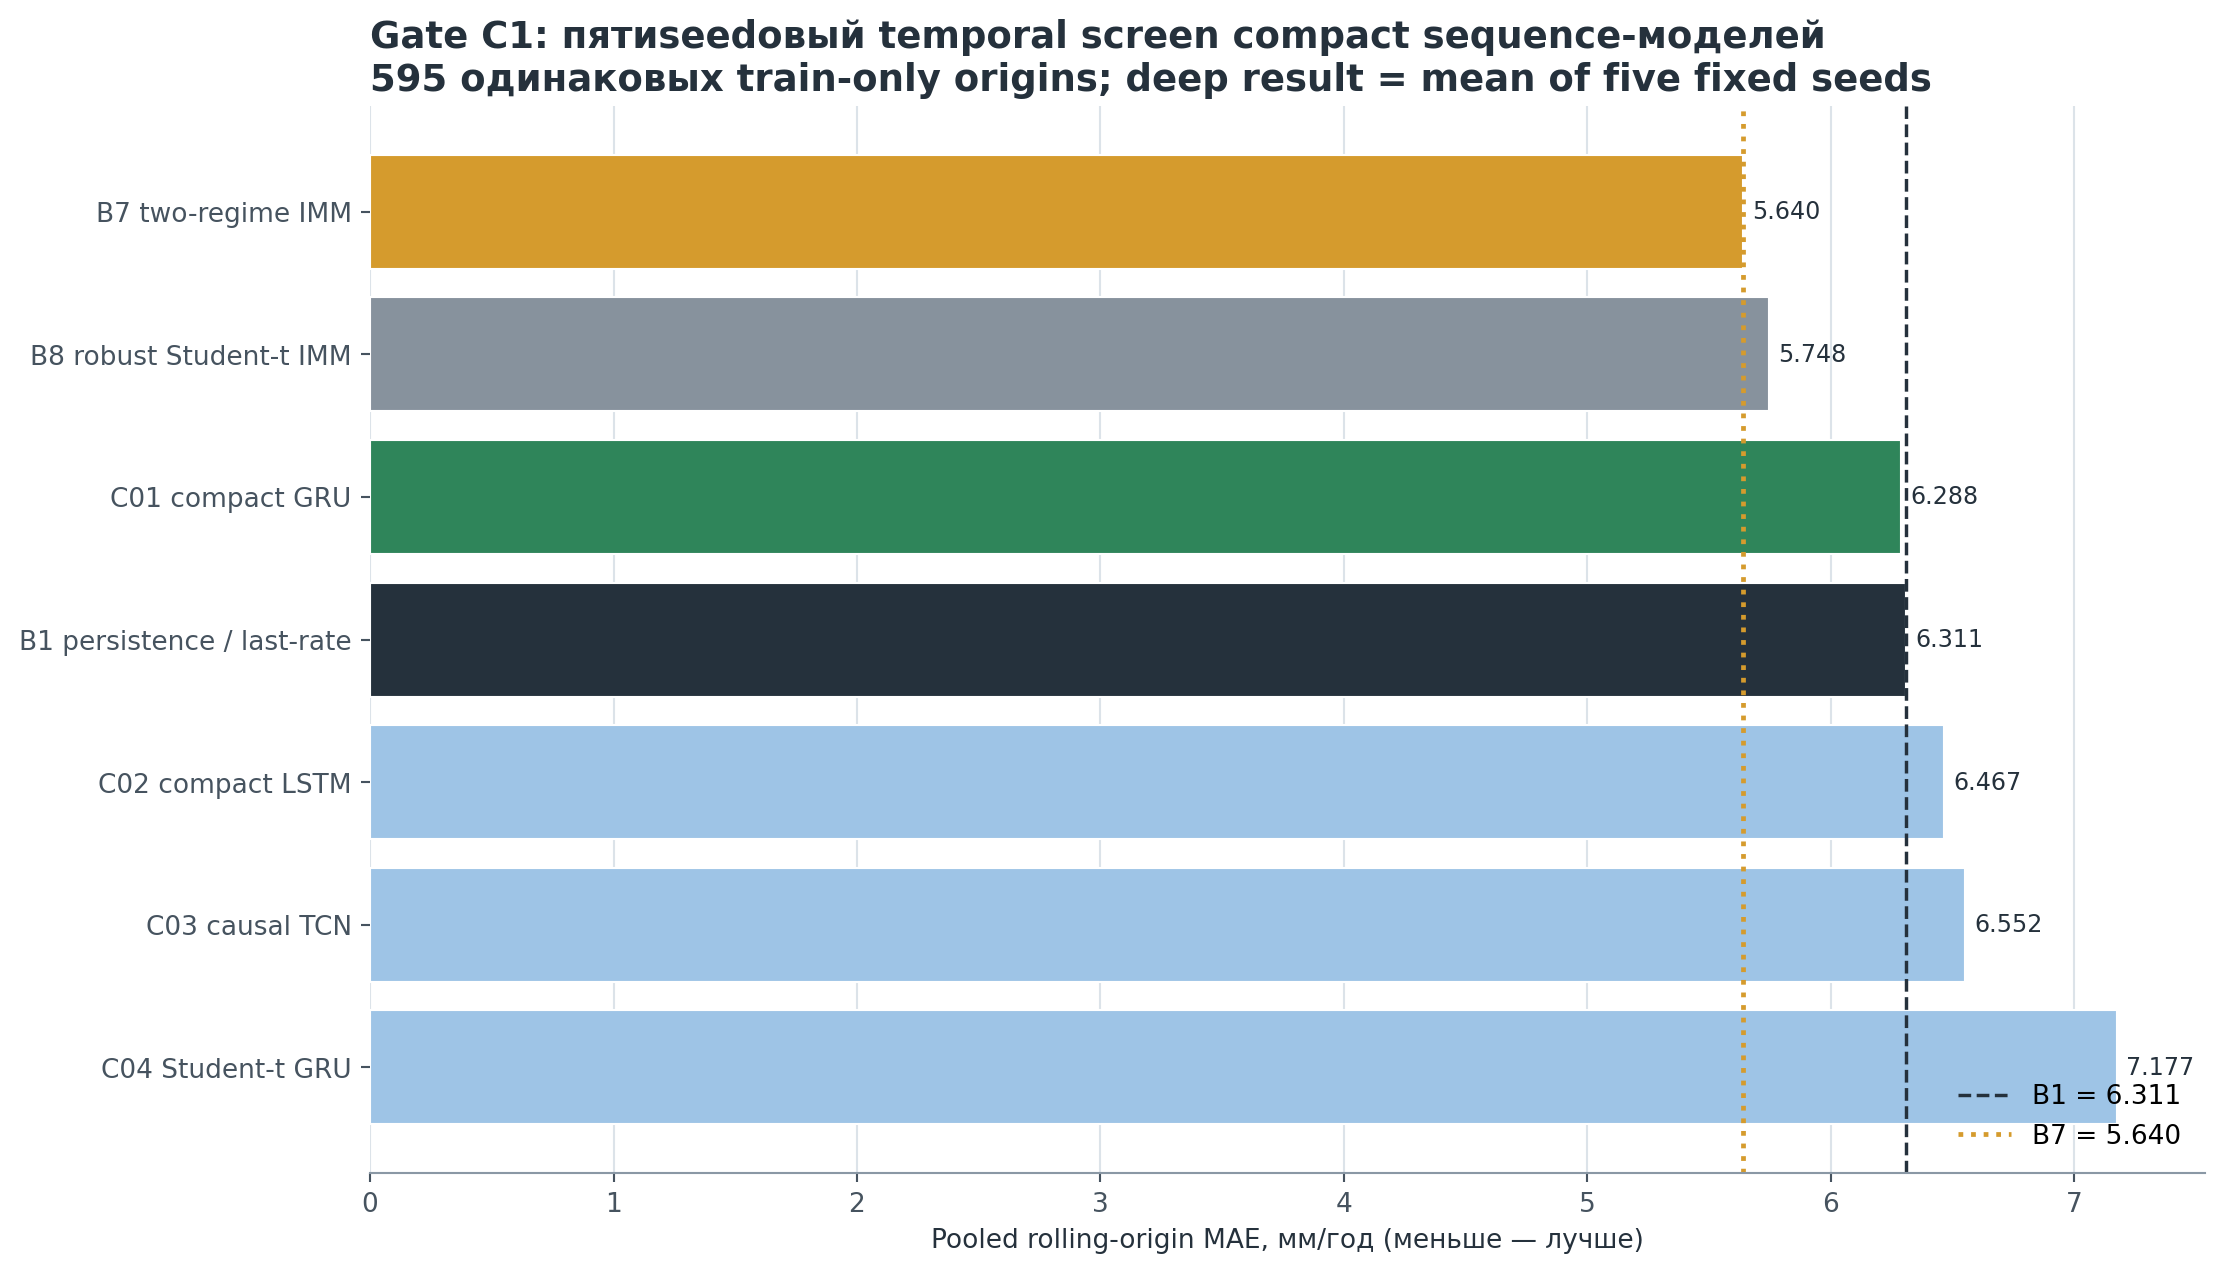

In [2]:
display(Image(filename=str(artifact / 'figures' / '01_ensemble_temporal_mae.png'), width=1150))

In [3]:
canonical = pd.concat([
    aggregate.loc[aggregate['model_id'].isin(['B1_persistence_last_rate', 'B7_two_regime_imm', 'B8_student_t_robust_imm'])],
    aggregate.loc[aggregate['model_id'].str.startswith('C0') & aggregate['aggregation'].eq('mean_of_fixed_seeds')],
]).sort_values(['mae', 'model_id'])
canonical[['model_id', 'mae', 'median_fold_mae', 'rmse', 'bias', 'b1_skill', 'max_fold_mae_ratio_vs_b1']].round(4)

,model_id,mae,median_fold_mae,rmse,bias,b1_skill,max_fold_mae_ratio_vs_b1
4,B7_two_regime_imm,5.6397,5.7439,9.9832,-0.7732,0.1064,1.2489
5,B8_student_t_robust_imm,5.7483,5.7642,10.2420,-0.8573,0.0892,1.4537
0,C01_compact_gru,6.2879,6.4567,10.8172,-0.7664,0.0037,1.8072
6,B1_persistence_last_rate,6.3110,6.2782,10.8095,-0.7748,0.0000,1.0000
1,C02_compact_lstm,6.4666,7.1275,11.3405,-0.9929,-0.0247,1.9444
2,C03_causal_tcn,6.5519,6.9500,11.1259,-1.3995,-0.0382,1.6263
3,C04_probabilistic_gru_student_t,7.1774,7.7141,13.6980,-3.1787,-0.1373,1.7261


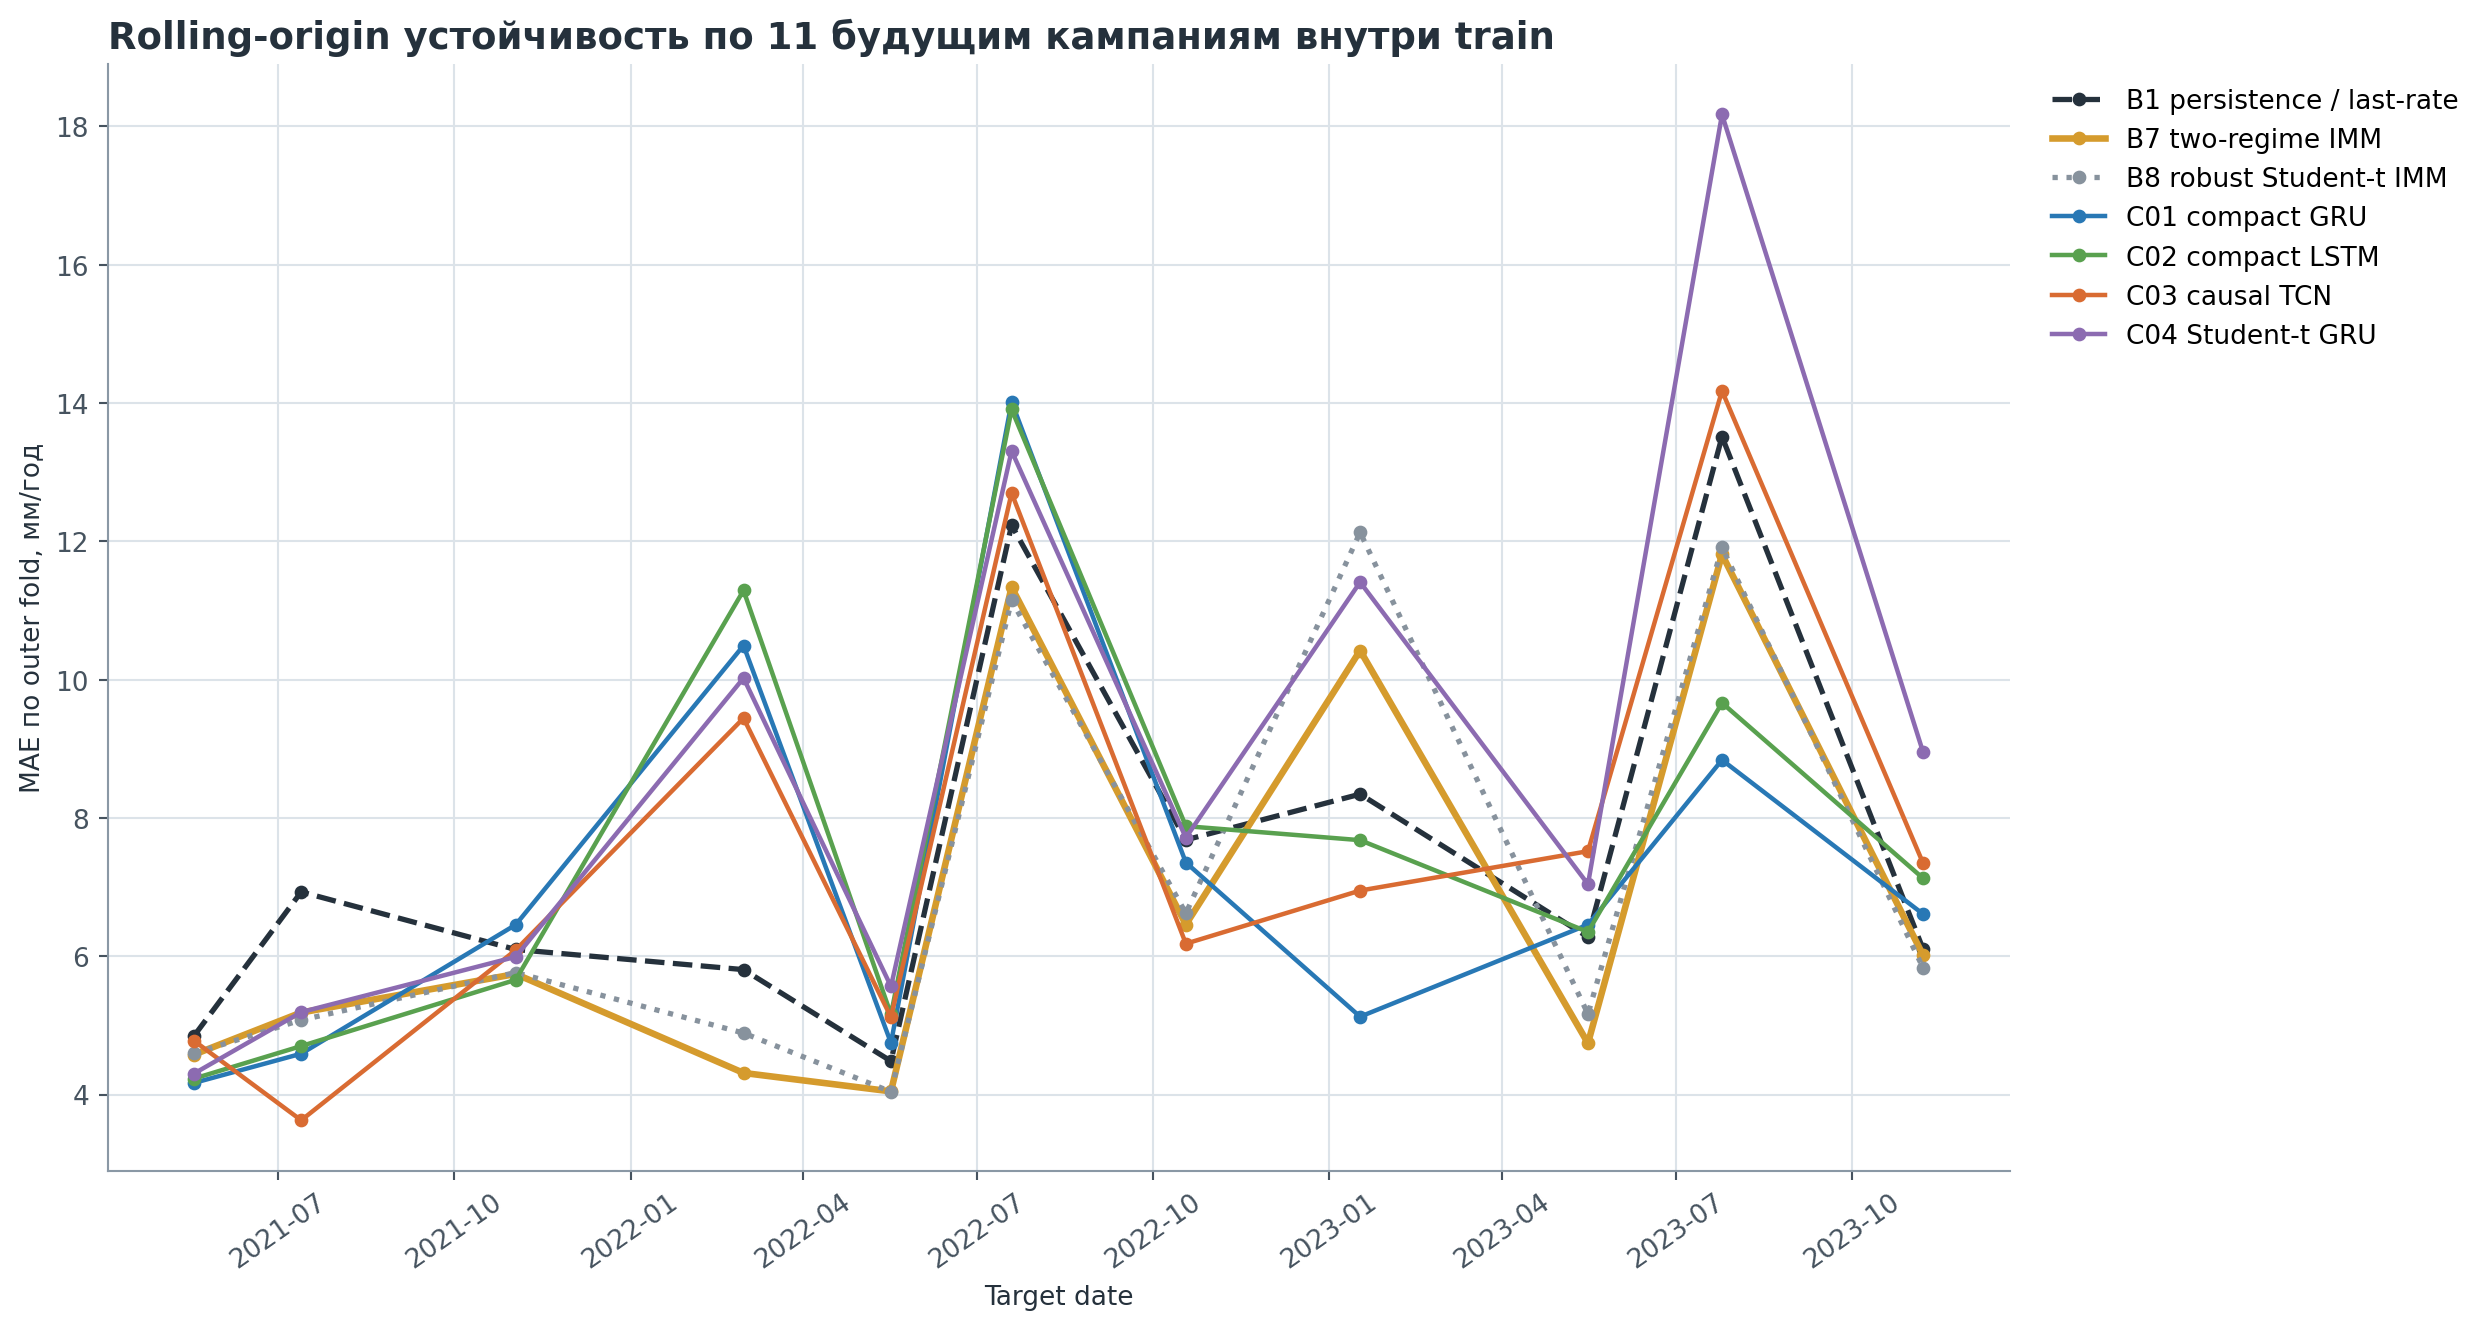

In [4]:
display(Image(filename=str(artifact / 'figures' / '02_rolling_mae_by_target_date.png'), width=1250))

Покампанийная кривая нужна не для нового подбора, а для проверки того, не скрывает ли pooled MAE отдельный провальный outer fold. Admission использует только заранее замороженные temporal guards.

## 2. Seed stability и вычислительная цена

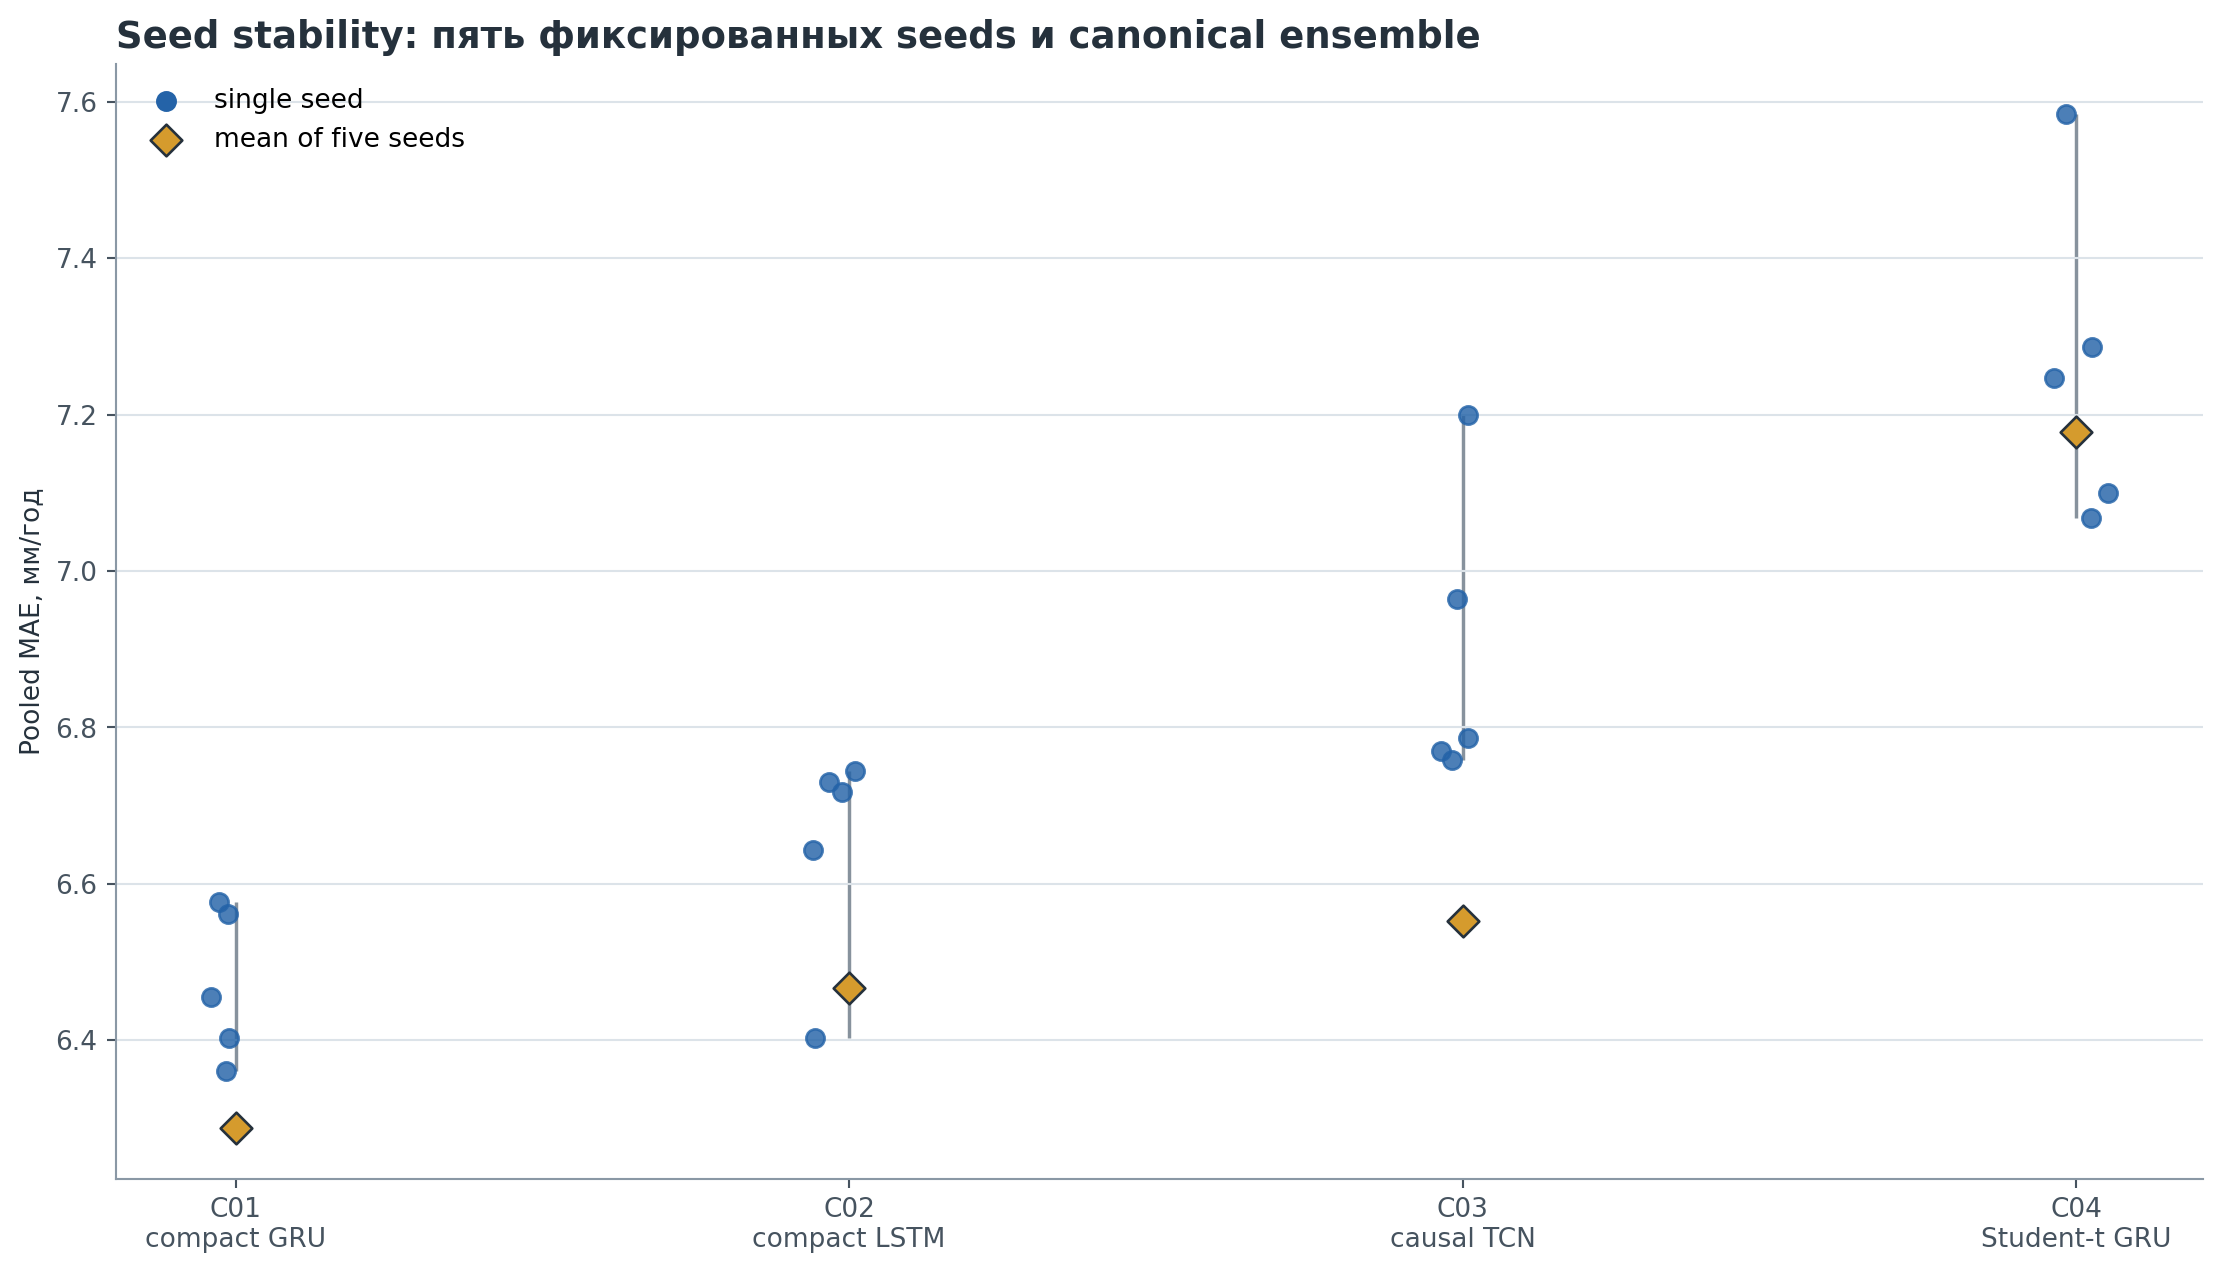

,model_id,seeds,seed_mae_mean,seed_mae_median,seed_mae_iqr,seed_mae_cv,seed_mae_min,seed_mae_max,seed_mae_range,ensemble_mae,ensemble_gain_vs_median_seed,dates_improved_vs_b1,dates_improved_vs_b7,seed_iqr_descriptive_pass,seed_cv_descriptive_pass
0,C01_compact_gru,5,6.4713,6.4556,0.1582,0.0132,6.3603,6.5772,0.2169,6.2879,0.1677,5,4,True,True
1,C02_compact_lstm,5,6.6475,6.7177,0.0871,0.0192,6.4026,6.7447,0.3421,6.4666,0.2511,5,5,True,True
2,C03_causal_tcn,5,6.8958,6.7869,0.1940,0.0246,6.7588,7.2000,0.4412,6.5519,0.2351,5,3,True,True
3,C04_probabilistic_gru_student_t,5,7.2568,7.2469,0.1866,0.0253,7.0673,7.5839,0.5165,7.1774,0.0695,3,1,True,True


In [5]:
display(Image(filename=str(artifact / 'figures' / '03_seed_stability.png'), width=1150))
seeds.round(4)

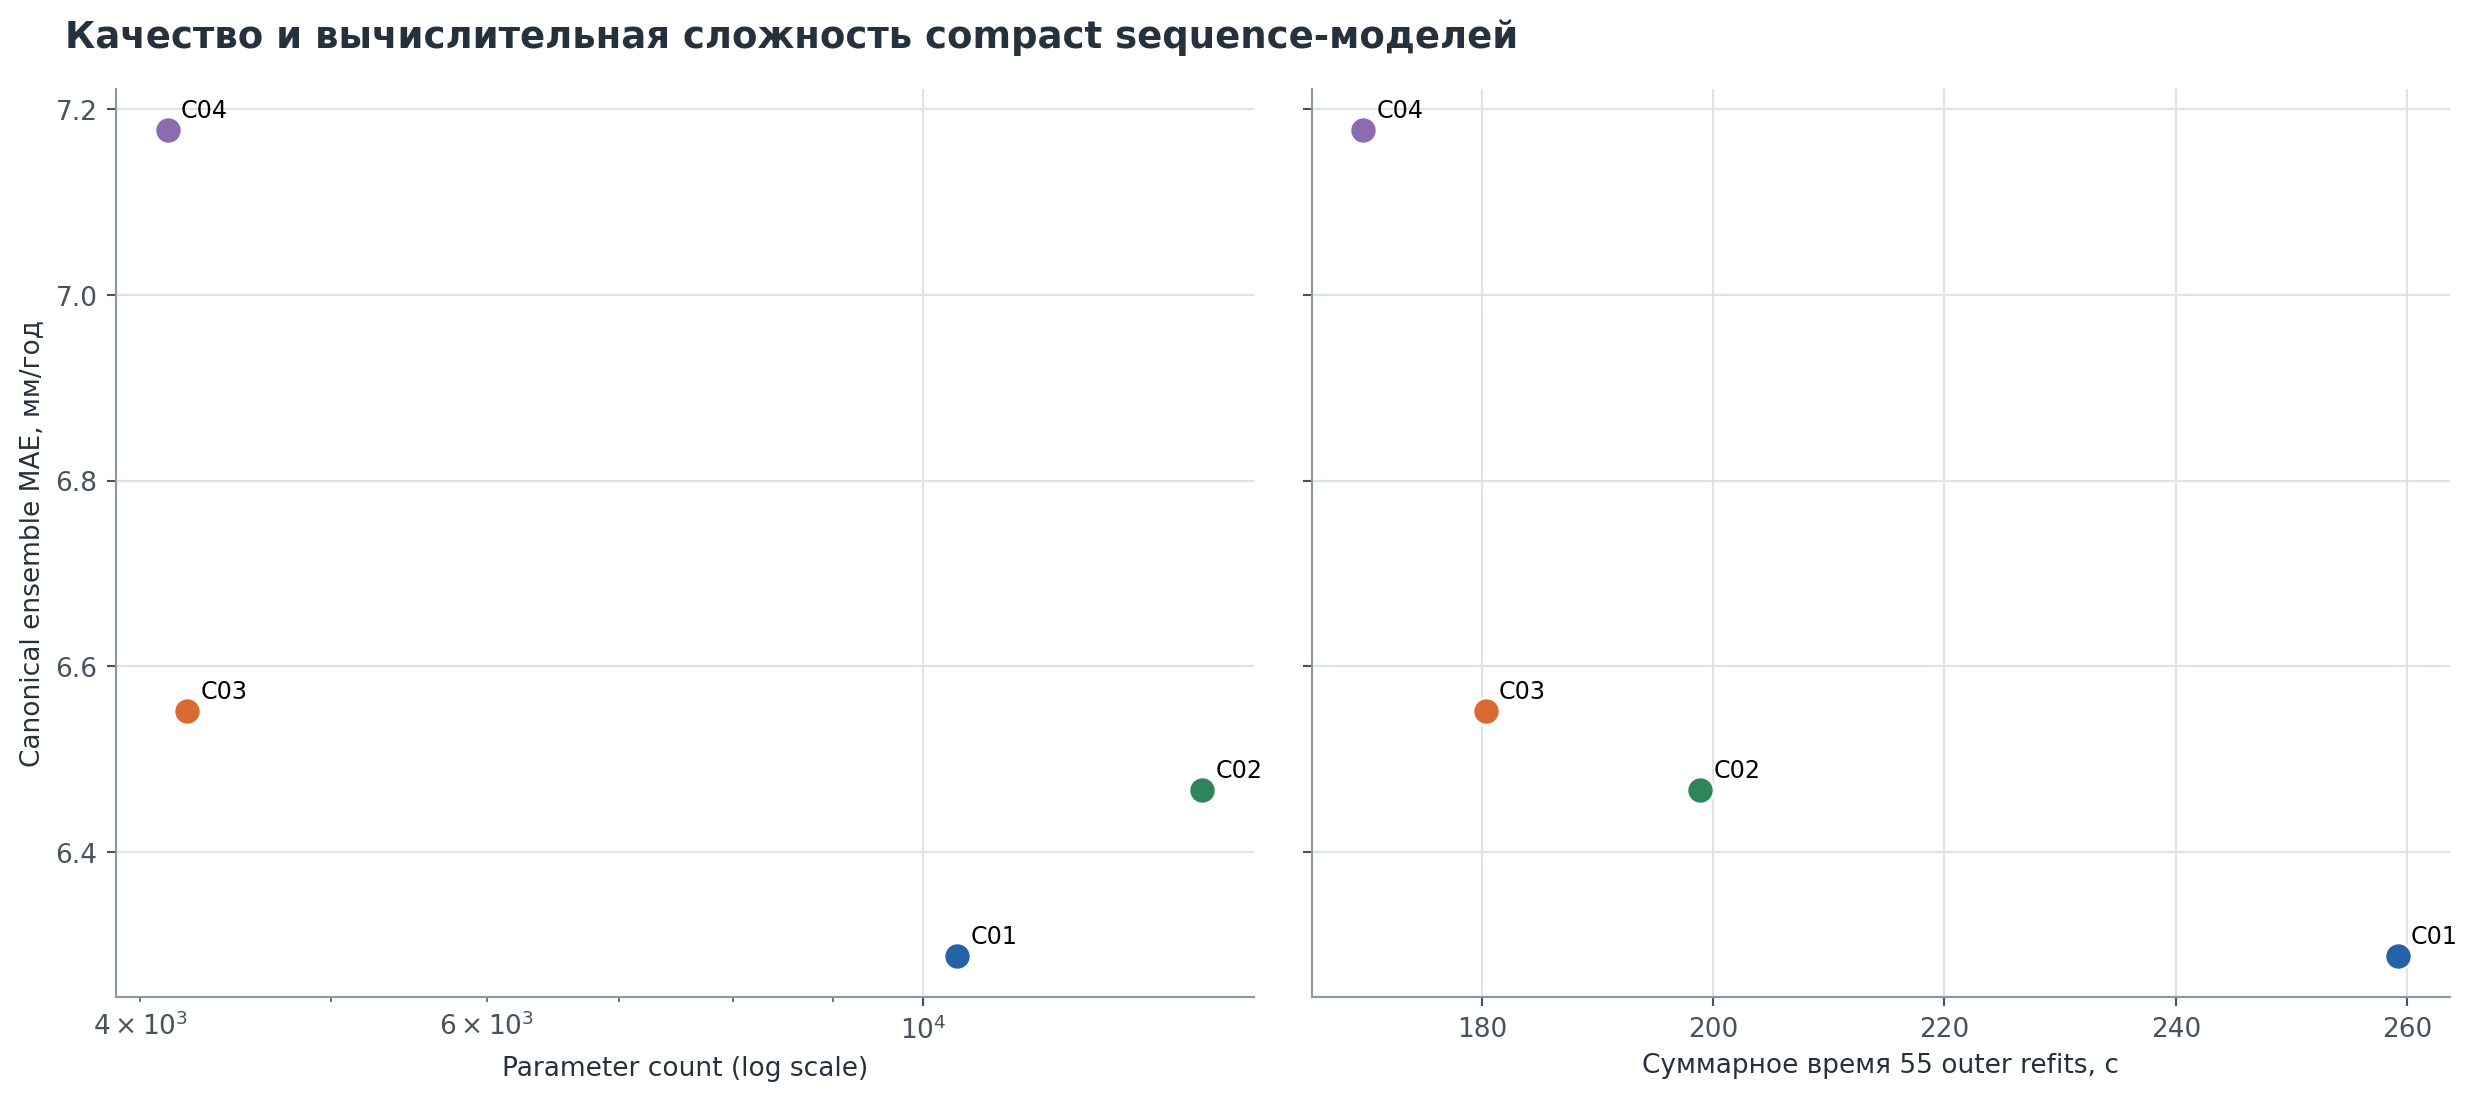

,model_id,logical_inner_evaluations,physical_inner_fits_executed,physical_inner_fits_reused,outer_refits,inner_fit_seconds_logical_sum,outer_fit_seconds,outer_inference_seconds,peak_ram_mb,peak_vram_mb,parameter_count_min,parameter_count_max,epoch_count_min,epoch_count_max
0,C01_compact_gru,2640,1040,1600,55,19846.983,259.194,0.068,1782.309,87.990,1265,10401,21,193
1,C02_compact_lstm,2640,1040,1600,55,18792.090,198.868,0.069,1782.383,88.470,1681,13857,13,159
2,C03_causal_tcn,2640,1040,1600,55,14329.990,180.354,0.081,1573.969,65.675,961,4225,9,171
3,C04_probabilistic_gru_student_t,1320,520,800,55,15022.645,169.758,0.104,1883.684,76.087,1299,4131,11,66


In [6]:
display(Image(filename=str(artifact / 'figures' / '04_mae_vs_complexity.png'), width=1250))
compute.round(3)

### Checkpoint trace и matched CUDA benchmark

In [7]:
checkpoint_summary = checkpoints.groupby('role', as_index=False).agg(
    manifests=('fit_id', 'nunique'),
    retained_states=('retained_checkpoint_count', 'sum'),
    bytes=('ranked_checkpoint_bytes', 'sum'),
    resumed=('resumed_from_recovery', 'sum'),
)
assert len(checkpoints) == 3860
assert checkpoints['keep_top_k'].eq(5).all()
assert not checkpoints['outer_labels_used_for_ranking'].astype(bool).any()
checkpoint_summary

,role,manifests,retained_states,bytes,resumed
0,inner,3640,18200,1323981360,0
1,outer,220,1100,90894160,0


In [8]:
benchmark = incidents['incidents'][-1]['matched_runtime_benchmark']
{
    'scope': benchmark['comparison_scope'],
    'fits_each_run': benchmark['fits_each_run'],
    'old_mean_seconds': round(benchmark['old_mean_fit_seconds'], 3),
    'new_mean_seconds_including_top5_io': round(benchmark['new_mean_fit_seconds_including_checkpointing'], 3),
    'mean_speedup': round(benchmark['mean_speedup_ratio'], 3),
    'median_speedup': round(benchmark['median_speedup_ratio'], 3),
}

{'scope': 'same model, fold, 16 configurations, three inner folds and five seeds; new timings include top-five persistence',
 'fits_each_run': 240,
 'old_mean_seconds': 4.449,
 'new_mean_seconds_including_top5_io': 3.301,
 'mean_speedup': 1.348,
 'median_speedup': 1.572}

Recovery state фиксируется после каждой завершённой 50-epoch стадии и на terminal epoch. Inner fits хранят top-5 по frozen early-stopping metric и восстанавливают rank 1. Outer refits хранят последние пять эпох и всегда выбирают preregistered final epoch; outer labels никогда не участвуют в ранжировании.

## 3. Native Student-t diagnostics

In [9]:
native.loc[native['scope'].eq('seed_aggregate')].round(4)

,scope,seed,fold_id,rows,crps,nll,coverage_50,mean_width_50,median_width_50,interval_score_50,...,mean_width_80,median_width_80,interval_score_80,coverage_95,mean_width_95,median_width_95,interval_score_95,mean_interval_width,median_interval_width,mean_interval_score
55,seed_aggregate,42117,ALL,595,5.4858,3.5146,0.3866,6.5379,5.7813,24.3776,...,13.8371,12.1346,41.0086,0.8924,26.3237,22.7091,83.9544,15.5662,12.4428,49.7802
56,seed_aggregate,42118,ALL,595,5.7724,3.5784,0.3445,6.7015,5.6939,25.7171,...,14.2409,11.9935,41.6883,0.8975,27.2839,22.3890,84.4052,16.0754,12.2224,50.6035
57,seed_aggregate,42119,ALL,595,5.4188,3.5073,0.3916,6.6122,5.6445,24.0081,...,14.0939,11.9212,40.2555,0.9025,27.1903,22.4868,81.0878,15.9654,12.2646,48.4505
58,seed_aggregate,42120,ALL,595,5.6036,3.5517,0.3714,6.4180,5.5752,24.8056,...,13.6641,11.7300,41.8585,0.8874,26.2958,22.0929,86.5553,15.4593,12.0287,51.0731
59,seed_aggregate,42121,ALL,595,5.5322,3.5379,0.3479,6.7349,5.7159,24.5676,...,14.3641,12.0479,40.4818,0.8958,27.7458,22.7387,82.1660,16.2816,12.3136,49.0718


Native Student-t метрики в C1 публикуются отдельно по seeds. Ensemble содержит только арифметическое среднее point predictions: усреднённая псевдо-Student-t distribution не создаётся. Полная mixture/calibration процедура остаётся Gate C2.

## 4. Admission и leakage boundary

In [10]:
screen.set_index('model_id')[[
    'status', 'pooled_mae', 'pooled_mae_ratio_vs_b1',
    'median_fold_mae_ratio_vs_b1', 'max_fold_mae_ratio_vs_b1', 'admitted_to_c2'
]].round(4)

,status,pooled_mae,pooled_mae_ratio_vs_b1,median_fold_mae_ratio_vs_b1,max_fold_mae_ratio_vs_b1,admitted_to_c2
model_id,,,,,,
C01_compact_gru,PASSED_TEMPORAL_SCREEN,6.2879,0.9963,1.0284,1.8072,True
C02_compact_lstm,REJECTED_TEMPORAL_SCREEN,6.4666,1.0247,1.1353,1.9444,False
C03_causal_tcn,REJECTED_TEMPORAL_SCREEN,6.5519,1.0382,1.1070,1.6263,False
C04_probabilistic_gru_student_t,REJECTED_TEMPORAL_SCREEN,7.1774,1.1373,1.2287,1.7261,False


In [11]:
assert validation['status'] == 'PASS_C1_TEMPORAL_SCREEN'
assert validation['failed_checks'] == 0
assert ledger['access_event'] == 1
assert ledger['all_shards_hash_frozen_before_access'] is True
assert ledger['worker_outer_validation_labels_loaded'] is False
assert admission['historical_validation_loaded'] is False
assert admission['current_test_loaded'] is False
assert admission['new_holdout_seen'] is False
assert admission['profile_zone_transition_audit_executed'] is False
assert admission['conformal_calibration_executed'] is False
assert admission['suite_v5_created'] is False
assert figures['model_training_calls'] == 0
{
    'outer_label_access_events': ledger['access_event'],
    'historical_validation_loaded': admission['historical_validation_loaded'],
    'current_test_loaded': admission['current_test_loaded'],
    'new_holdout_seen': admission['new_holdout_seen'],
    'profile_zone_transition_audit': admission['profile_zone_transition_audit_executed'],
    'suite_v5_created': admission['suite_v5_created'],
}

{'outer_label_access_events': 1,
 'historical_validation_loaded': False,
 'current_test_loaded': False,
 'new_holdout_seen': False,
 'profile_zone_transition_audit': False,
 'suite_v5_created': False}

## Ограничения и следующий этап

Gate C1 отвечает только на вопрос о temporal admission. Он не доказывает пространственную переносимость, устойчивость transition/gap режимов, калибровку общих conformal-интервалов или внешнюю обобщаемость. Эти проверки остаются `PENDING` в Gate C2; единственная финальная проверка должна выполняться один раз на новом real future/external holdout после заморозки suite v5 или fallback B7.